<a href="https://colab.research.google.com/github/juheesun/-/blob/main/%EC%B6%94%EC%B2%9C%EC%8B%9C%EC%8A%A4%ED%85%9C_%EC%9D%B4%EC%9B%83%EA%B8%B0%EB%B0%98_%ED%95%99%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
모델 비교 검증 시작...
K=10 평가 완료
K=20 평가 완료
K=30 평가 완료
K=40 평가 완료
K=50 평가 완료

             모델 성능 비교 결과 (Validation)
 K  User_RMSE  Item_RMSE  User_MAE  Item_MAE
10   0.938349   1.033922  0.732848  0.760988
20   0.925109   1.169032  0.722423  0.821398
30   0.923326   1.302510  0.720886  0.897009
40   0.924122   1.430061  0.721336  0.977676
50   0.924333   1.528868  0.721827  1.045746


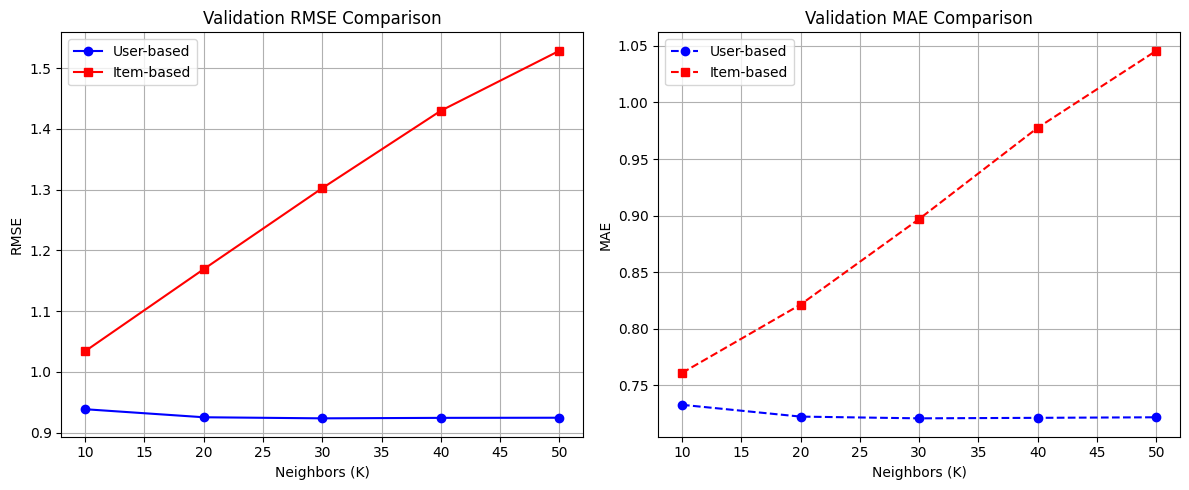


✅ 최종 선정: USER-BASED (K=30)


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pickle
import math
import matplotlib.pyplot as plt
from google.colab import drive

# 0. 드라이브 마운트
drive.mount('/content/drive')

# 1. 데이터 로드 및 분할
base_path = '/content/drive/MyDrive/Recommender_systems/ml-100k/'
train_full = pd.read_csv(base_path + 'ua.base', sep='\t', names=['user_id', 'item_id', 'rating', 'ts'])
train_data, val_data = train_test_split(train_full, test_size=0.1, random_state=42)

# 2. 전처리: Mean-Centering
train_matrix = train_data.pivot(index='user_id', columns='item_id', values='rating')
user_mean = train_matrix.mean(axis=1)
train_matrix_centered = train_matrix.sub(user_mean, axis=0).fillna(0)

# 3. 유사도 계산
user_sim_df = pd.DataFrame(cosine_similarity(train_matrix_centered), index=train_matrix.index, columns=train_matrix.index)
item_sim_df = pd.DataFrame(cosine_similarity(train_matrix_centered.T), index=train_matrix.columns, columns=train_matrix.columns)

# 4. 예측 함수
def predict(user_id, item_id, kind='user', k=30):
    if kind == 'user':
        if user_id not in user_sim_df.index or item_id not in train_matrix.columns: return 3.0
        sim_scores = user_sim_df[user_id]
        rated_users = train_matrix[item_id][train_matrix[item_id] > 0].index
        top_k = sim_scores[rated_users].sort_values(ascending=False).head(k)
        if top_k.abs().sum() == 0: return user_mean[user_id]
        return user_mean[user_id] + (np.dot(top_k, train_matrix_centered.loc[top_k.index, item_id]) / top_k.abs().sum())
    else:
        if item_id not in item_sim_df.index or user_id not in train_matrix.index: return 3.0
        sim_scores = item_sim_df[item_id]
        rated_items = train_matrix.loc[user_id][train_matrix.loc[user_id] > 0].index
        top_k = sim_scores[rated_items].sort_values(ascending=False).head(k)
        if top_k.abs().sum() == 0: return user_mean[user_id]
        return np.dot(top_k, train_matrix.loc[user_id, top_k.index]) / top_k.abs().sum()

# 5. 모델별 K값 비교 실험 (RMSE & MAE 추가)
k_list = [10, 20, 30, 40, 50]
results = []

print("모델 비교 검증 시작...")
for k in k_list:
    u_preds = [predict(u, i, kind='user', k=k) for u, i in zip(val_data['user_id'], val_data['item_id'])]
    i_preds = [predict(u, i, kind='item', k=k) for u, i in zip(val_data['user_id'], val_data['item_id'])]

    u_rmse = math.sqrt(mean_squared_error(val_data['rating'], u_preds))
    i_rmse = math.sqrt(mean_squared_error(val_data['rating'], i_preds))
    u_mae = mean_absolute_error(val_data['rating'], u_preds)
    i_mae = mean_absolute_error(val_data['rating'], i_preds)

    results.append({
        'K': k,
        'User_RMSE': u_rmse, 'Item_RMSE': i_rmse,
        'User_MAE': u_mae, 'Item_MAE': i_mae
    })
    print(f"K={k} 평가 완료")

# 6. 결과 테이블 출력
res_df = pd.DataFrame(results)
print("\n" + "="*50)
print("             모델 성능 비교 결과 (Validation)")
print("="*50)
print(res_df.to_string(index=False))
print("="*50)

# 7. 결과 시각화
plt.figure(figsize=(12, 5))

# RMSE 그래프
plt.subplot(1, 2, 1)
plt.plot(res_df['K'], res_df['User_RMSE'], marker='o', label='User-based', color='blue')
plt.plot(res_df['K'], res_df['Item_RMSE'], marker='s', label='Item-based', color='red')
plt.title('Validation RMSE Comparison')
plt.xlabel('Neighbors (K)')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)

# MAE 그래프
plt.subplot(1, 2, 2)
plt.plot(res_df['K'], res_df['User_MAE'], marker='o', ls='--', label='User-based', color='blue')
plt.plot(res_df['K'], res_df['Item_MAE'], marker='s', ls='--', label='Item-based', color='red')
plt.title('Validation MAE Comparison')
plt.xlabel('Neighbors (K)')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 8. 최적 모델 저장
best_row = res_df.loc[res_df['User_RMSE'].idxmin()]
best_k = int(best_row['K'])

model_data = {
    'train_matrix': train_matrix.fillna(0),
    'train_matrix_centered': train_matrix_centered,
    'user_sim': user_sim_df,
    'item_sim': item_sim_df,
    'user_mean': user_mean,
    'best_k': best_k,
    'best_kind': 'user'
}

with open(base_path + 'model_final_v3.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print(f"\n최종 선정: USER-BASED (K={best_k})")